# Housing Market Simulation

This notebook runs a discrete-event housing market simulation and reconstructs
all analytics exclusively from the **event log**. Nine renters with modest
incomes compete for five houses; most cannot sustain rent indefinitely, so
eviction and re-bidding cycles dominate the dynamics.

In [ ]:
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path("../..").resolve()))
os.environ["DISABLE_PANDERA_IMPORT_WARNING"] = "True"

import matplotlib.pyplot as plt

from analytics.bronze import build_fact_table
from analytics.gold import (
    build_house_rents,
    build_housed_renter_wealth,
    build_occupancy_timeline,
    build_rent_comparison,
    build_rent_payments,
    build_renter_wealth,
    build_time_to_rent_rolling,
    build_vacancy_count,
)
from analytics.silver import (
    project_asking_rent,
    project_occupancy,
    project_rent_payments,
    project_time_to_rent,
    project_wealth,
)
from core import (
    Agent,
    AgentIncomeReceived,
    AuctionClear,
    CompositeAgentPolicy,
    EventQueue,
    HomelessBiddingPolicy,
    House,
    HousingMarket,
    IncomePolicy,
    SignalRegistry,
    SimulationEngine,
    SimulationSettings,
    VacantState,
)
from viz import (
    plot_avg_rent,
    plot_house_rents,
    plot_housed_renter_wealth,
    plot_occupancy,
    plot_paid_vs_asked,
    plot_renter_wealth,
    plot_time_to_rent,
    plot_vacancy,
)

## Market Setup

- **Landlord** owns all five houses and earns no external income (lives off rent).
- Nine renters (**Alice -- Ivy**) have modest incomes that, for most agents,
  fall short of covering rent. Each uses a composite policy that collects income
  and bids on vacant houses when homeless.
- Rent is paid every period; tenants who cannot pay are evicted. With four
  agents always homeless, competition for vacancies is constant.

In [2]:
settings = SimulationSettings(vacancy_decay_rate=0.005)

owner_policy = IncomePolicy()
renter_policy = CompositeAgentPolicy(policies=(IncomePolicy(), HomelessBiddingPolicy()))

landlord = Agent(
    id="landlord",
    money=100,
    income=0,
    spend_rate=0.0,
    policy=owner_policy,
)

renter_specs = [
    # (id,       money, income, spend_rate)
    ("alice", 10, 8, 0.60),
    ("bob", 5, 6, 0.70),
    ("carol", 8, 7, 0.65),
    ("dave", 7, 6, 0.60),
    ("eve", 4, 5, 0.75),
    ("frank", 9, 7, 0.62),
    ("grace", 3, 4, 0.80),
    ("hank", 6, 6, 0.68),
    ("ivy", 8, 7, 0.62),
]
renters = tuple(
    Agent(id=name, money=money, income=inc, spend_rate=sr, policy=renter_policy)
    for name, money, inc, sr in renter_specs
)

house_specs = [
    # (id,        rent, age)
    ("house_a", 10.0, 10),
    ("house_b", 15.0, 7),
    ("house_c", 20.0, 5),
    ("house_d", 25.0, 3),
    ("house_e", 35.0, 1),
]
houses = tuple(
    House(id=hid, owner_id="landlord", state=VacantState(), rent_price=rent, age=age) for hid, rent, age in house_specs
)

market = HousingMarket(
    entities=(landlord, *renters, *houses),
    settings=settings,
)

queue = EventQueue()
for agent in market.agents:
    queue = queue.push(AgentIncomeReceived(time=0, agent_id=agent.id))
queue = queue.push(AuctionClear(time=0))

engine = SimulationEngine(market=market, queue=queue, registry=SignalRegistry())

In [3]:
N_STEPS = 150_000
MAX_T = 200
sim = engine

for _ in range(N_STEPS):
    if not sim.queue.events:
        break
    sim = sim.step()
    if sim.now >= MAX_T:
        break

event_log = list(sim.event_log)

Processed 15420 events, simulation time reached t=200.0


## Analytics (Medallion Architecture)

All downstream analysis follows a **Bronze / Silver / Gold** medallion architecture:

- **Bronze** -- raw event log materialised as a pandera-validated fact table.
- **Silver** -- cleaned projections derived solely from bronze (wealth, occupancy, rent payments, time-to-rent, asking rents).
- **Gold** -- business-ready tables derived solely from silver, consumed directly by plots.

In [4]:
# Bronze
facts = build_fact_table(event_log, market)

# Silver
wealth_s = project_wealth(facts, market)
occupancy_s = project_occupancy(facts, market)
rent_s = project_rent_payments(facts)
ttr_s = project_time_to_rent(facts, market)
asking_s = project_asking_rent(facts, market)

# Gold
renter_wealth_g = build_renter_wealth(wealth_s)
housed_wealth_g = build_housed_renter_wealth(wealth_s, occupancy_s)
rent_g = build_rent_payments(rent_s)
rent_cmp_g = build_rent_comparison(rent_s, asking_s)
house_rents_g = build_house_rents(asking_s)
occupancy_g = build_occupancy_timeline(occupancy_s)
vacancy_g = build_vacancy_count(occupancy_s)
ttr_g = build_time_to_rent_rolling(ttr_s)

Bronze facts:  14831 rows  |  {'bid': 10053, 'income': 2001, 'auction_clear': 2001, 'rent_collected': 405, 'rent_started': 187, 'evicted': 184}

Silver wealth:  2010 rows  |  201 unique times
Silver occ:     1005 rows  |  201 unique times
Silver rent:     405 rows
Silver ttr:      187 rows
Silver asking:  1005 rows

Gold vacancy:    201 rows
Gold ttr:        187 rows


## Visualizations

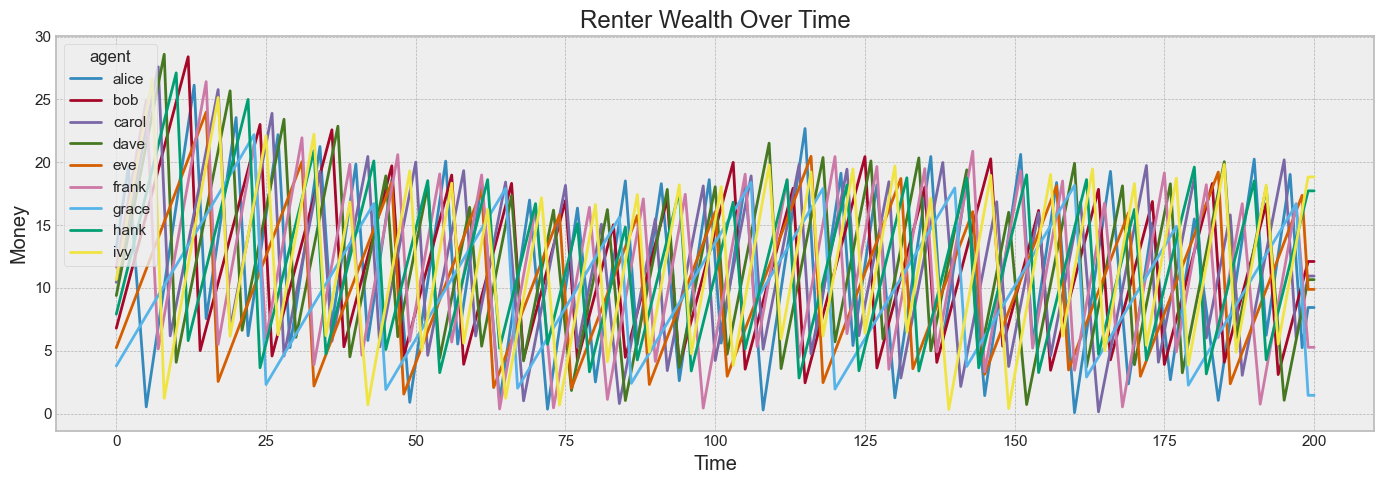

In [6]:
plot_renter_wealth(renter_wealth_g)
plt.show()

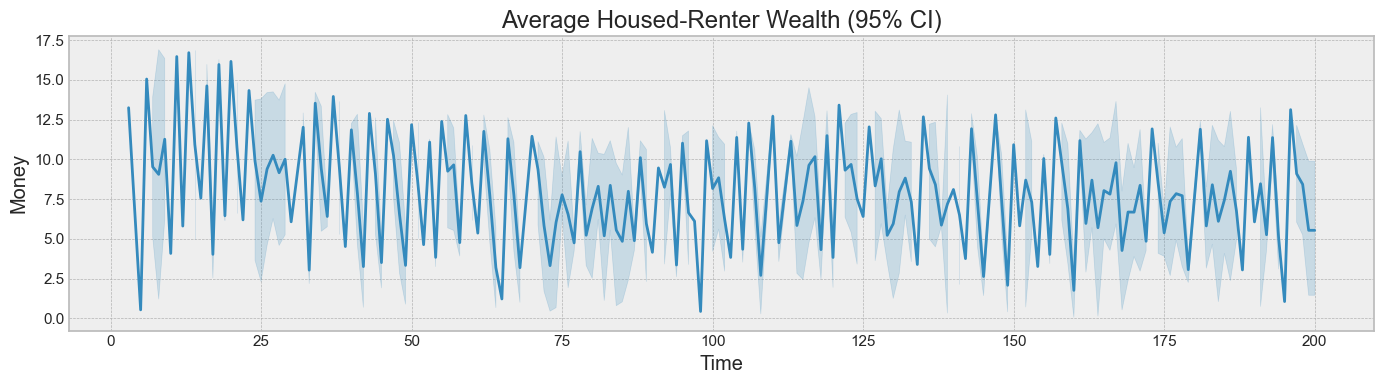

In [7]:
plot_housed_renter_wealth(housed_wealth_g)
plt.show()

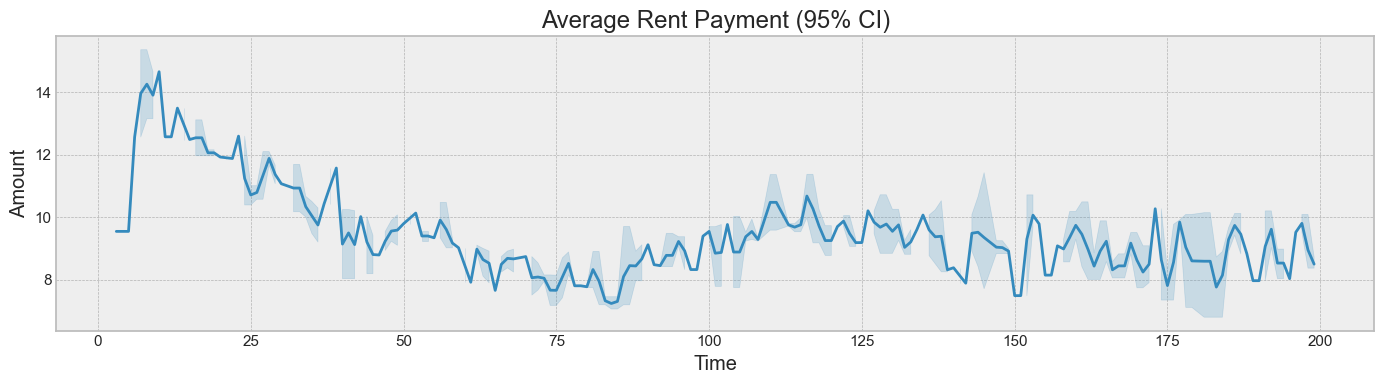

In [8]:
plot_avg_rent(rent_g)
plt.show()

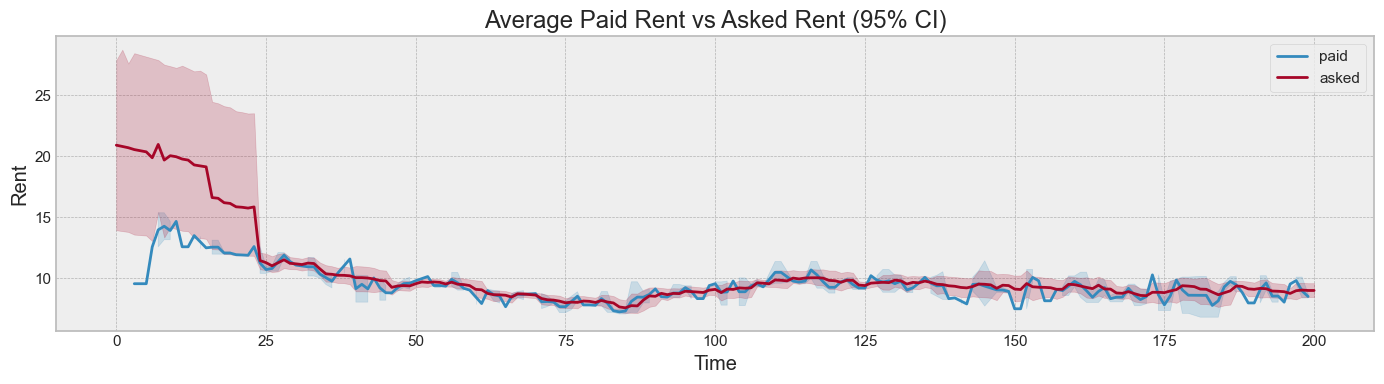

In [9]:
plot_paid_vs_asked(rent_cmp_g)
plt.show()

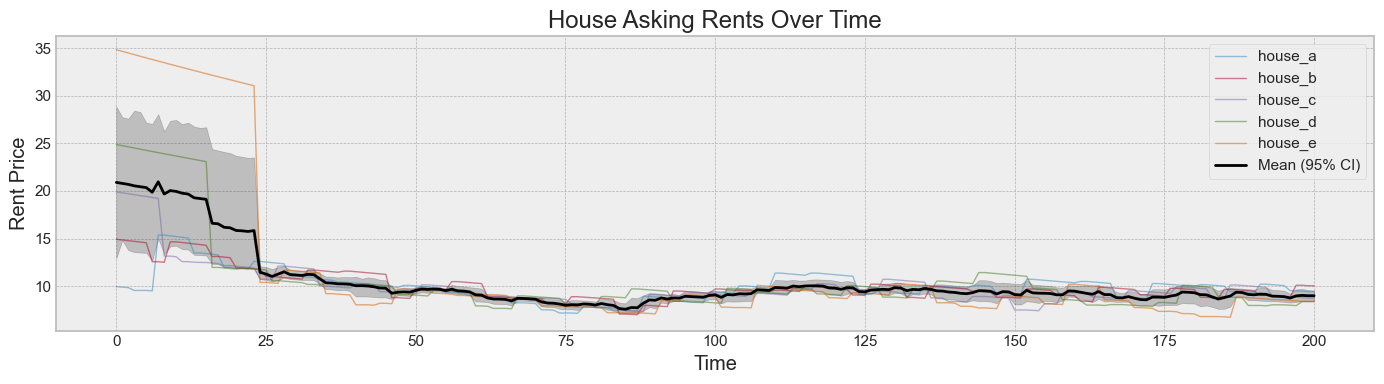

In [10]:
plot_house_rents(house_rents_g)
plt.show()

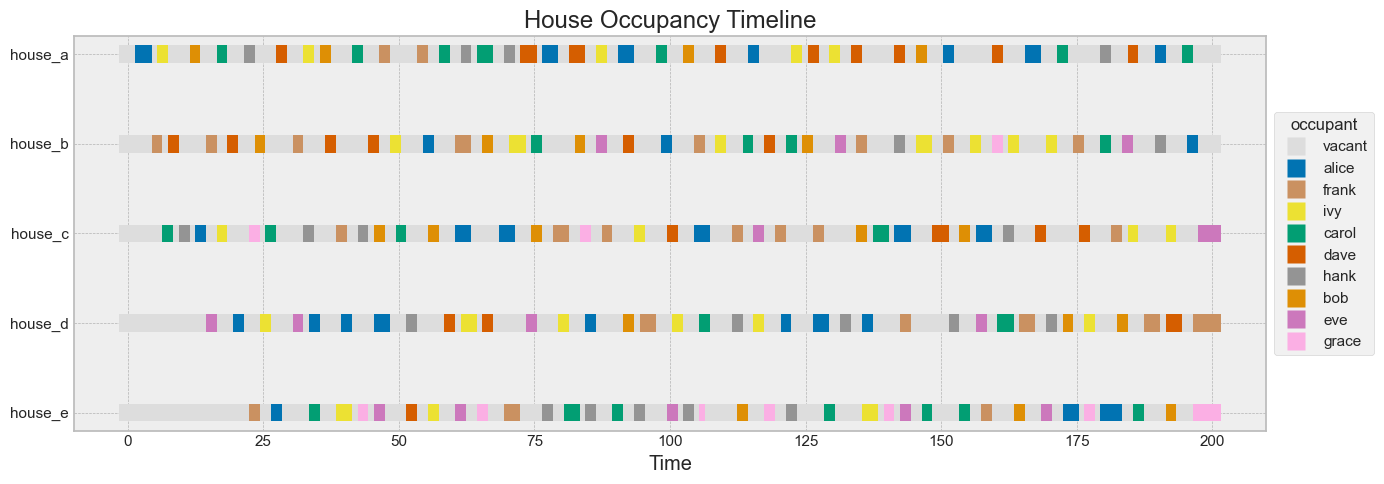

In [11]:
plot_occupancy(occupancy_g)
plt.show()

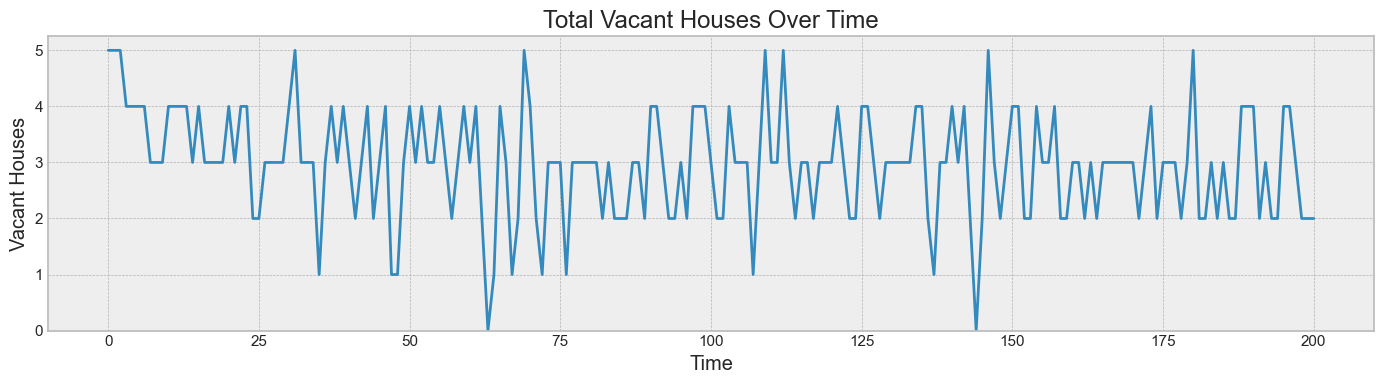

In [12]:
plot_vacancy(vacancy_g)
plt.show()

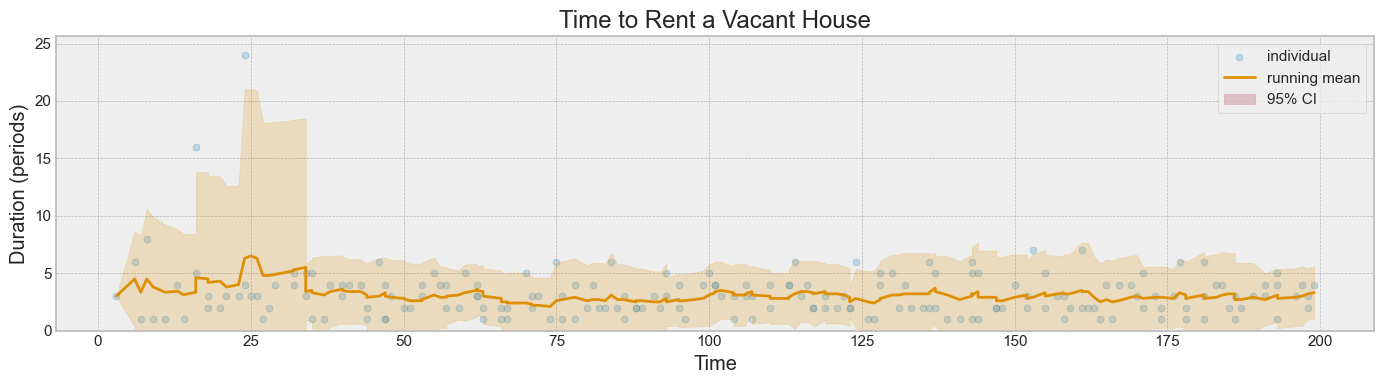

In [13]:
plot_time_to_rent(ttr_g)
plt.show()